In [1]:
pip install pandas numpy matplotlib seaborn jupyter ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("nigga")

nigga


--- 5 DÒNG ĐẦU SAU KHI CLEAN ---
      brand                            model  model_year   milage    price
0      Ford  Utility Police Interceptor Base        2013  51000.0  10300.0
1   Hyundai                     Palisade SEL        2021  34742.0  38005.0
2     Lexus                    RX 350 RX 350        2022  22372.0  54598.0
3  INFINITI                 Q50 Hybrid Sport        2015  88900.0  15500.0
4      Audi        Q3 45 S line Premium Plus        2021   9835.0  34999.0

--- THỐNG KÊ MÔ TẢ ---
        model_year         milage         price
count  4009.000000    4009.000000  4.009000e+03
mean   2015.515590   64717.551010  4.455319e+04
std       6.104816   52296.599459  7.871064e+04
min    1974.000000     100.000000  2.000000e+03
25%    2012.000000   23044.000000  1.720000e+04
50%    2017.000000   52775.000000  3.100000e+04
75%    2020.000000   94100.000000  4.999000e+04
max    2024.000000  405000.000000  2.954083e+06


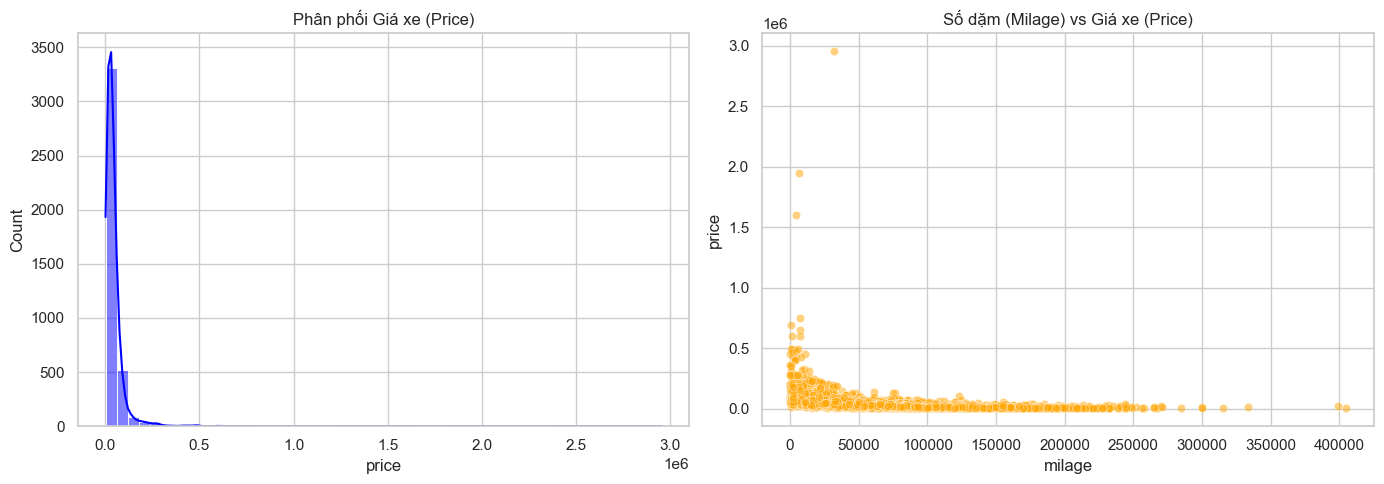

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('used_cars.csv')

# 2. Làm sạch dữ liệu (Data Cleaning)
# Xử lý cột price: Xóa '$', ',' và ép kiểu sang số thực (float)
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

# Xử lý cột milage: Xóa ' mi.', ',' và ép kiểu sang số thực (float)
df['milage'] = df['milage'].str.replace(' mi.', '').str.replace(',', '').astype(float)

# Xử lý các giá trị bị thiếu (Missing Values)
# Lấp đầy loại nhiên liệu bằng giá trị xuất hiện nhiều nhất (mode)
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
# Giả định các xe không có thông tin tai nạn là chưa từng bị
df['accident'] = df['accident'].fillna('None reported') 
# Đa số cột clean_title là 'Yes', nên ta điền các dòng trống bằng 'Yes'
df['clean_title'] = df['clean_title'].fillna('Yes') 

# 3. Kiểm tra lại sau khi làm sạch
print("--- 5 DÒNG ĐẦU SAU KHI CLEAN ---")
print(df[['brand', 'model', 'model_year', 'milage', 'price']].head())

print("\n--- THỐNG KÊ MÔ TẢ ---")
print(df.describe())

# 4. Trực quan hóa dữ liệu (EDA)
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Phân phối Giá xe
sns.histplot(df['price'], bins=50, kde=True, ax=axs[0], color='blue')
axs[0].set_title('Phân phối Giá xe (Price)')

# Biểu đồ 2: Tương quan giữa Số dặm (Milage) và Giá xe (Price)
sns.scatterplot(data=df, x='milage', y='price', ax=axs[1], color='orange', alpha=0.5)
axs[1].set_title('Số dặm (Milage) vs Giá xe (Price)')

plt.tight_layout()
plt.show()

--- 5 DÒNG ĐẦU SAU KHI MÃ HÓA ---
   brand  model   milage  fuel_type  engine  transmission  ext_col  int_col  \
0     13   1639  51000.0          1     572            14       20       10   
1     18   1106  34742.0          2     560            26      155       58   
2     26   1239  22372.0          2     537            33       29       10   
3     19   1164  88900.0          3     715            20       20       10   
4      3   1147   9835.0          2     198            26       98       10   

   accident  clean_title    price  car_age  
0         0            0  10300.0       11  
1         0            0  38005.0        3  
2         1            0  54598.0        2  
3         1            0  15500.0        9  
4         1            0  34999.0        3  


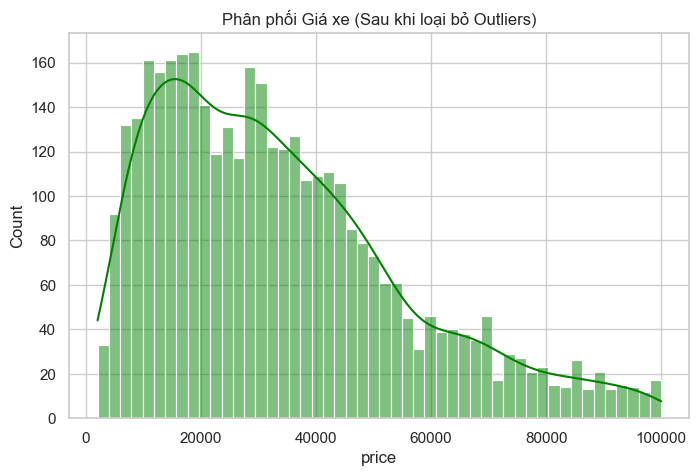

In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Loại bỏ Outliers (Giá trị ngoại lai) của Giá xe
# Chỉ giữ lại các xe có giá từ 1.000 đến 100.000 đô la để model tập trung học phân khúc phổ thông
df_cleaned = df[(df['price'] >= 1000) & (df['price'] <= 100000)].copy()

# 2. Feature Engineering (Kỹ thuật đặc trưng)
# Tạo cột 'car_age' (Tuổi đời xe) thay vì dùng năm sản xuất
df_cleaned['car_age'] = 2024 - df_cleaned['model_year']

# Xóa cột model_year vì đã được thay thế bằng car_age
df_cleaned = df_cleaned.drop(columns=['model_year'])

# 3. Mã hóa dữ liệu Text sang Number (Label Encoding)
encoder = LabelEncoder()
categorical_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

for col in categorical_cols:
    df_cleaned[col] = encoder.fit_transform(df_cleaned[col].astype(str))

# 4. Kiểm tra thành quả
print("--- 5 DÒNG ĐẦU SAU KHI MÃ HÓA ---")
print(df_cleaned.head())

# Vẽ lại biểu đồ xem phân phối Giá xe đã chuẩn chưa
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['price'], bins=50, kde=True, color='green')
plt.title('Phân phối Giá xe (Sau khi loại bỏ Outliers)')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Tách Features (X - Biến độc lập) và Target (y - Biến phụ thuộc)
X = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

# 2. Chia tập Train (80% để học) và Test (20% để kiểm tra)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# 3. Khởi tạo và Huấn luyện mô hình
# Sử dụng 100 cây quyết định (n_estimators=100)
model = RandomForestRegressor(n_estimators=100, random_state=42)
print("\nĐang huấn luyện mô hình (Training)...")
model.fit(X_train, y_train)

# 4. Dự đoán trên tập Test chưa từng nhìn thấy
y_pred = model.predict(X_test)

# 5. Đánh giá độ chính xác của mô hình
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"MAE (Sai số tuyệt đối trung bình): ${mae:,.2f}")
print(f"RMSE (Căn bậc hai sai số toàn phương): ${rmse:,.2f}")
print(f"R-squared (Độ phù hợp): {r2:.4f}")

Kích thước tập Train: (3020, 11)
Kích thước tập Test: (755, 11)

Đang huấn luyện mô hình (Training)...

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
MAE (Sai số tuyệt đối trung bình): $6,226.74
RMSE (Căn bậc hai sai số toàn phương): $8,817.58
R-squared (Độ phù hợp): 0.8318


C:\Users\dinhg\AppData\Local\Temp\ipykernel_7164\3890191685.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(features)[indices], palette='viridis', ax=axs[1])


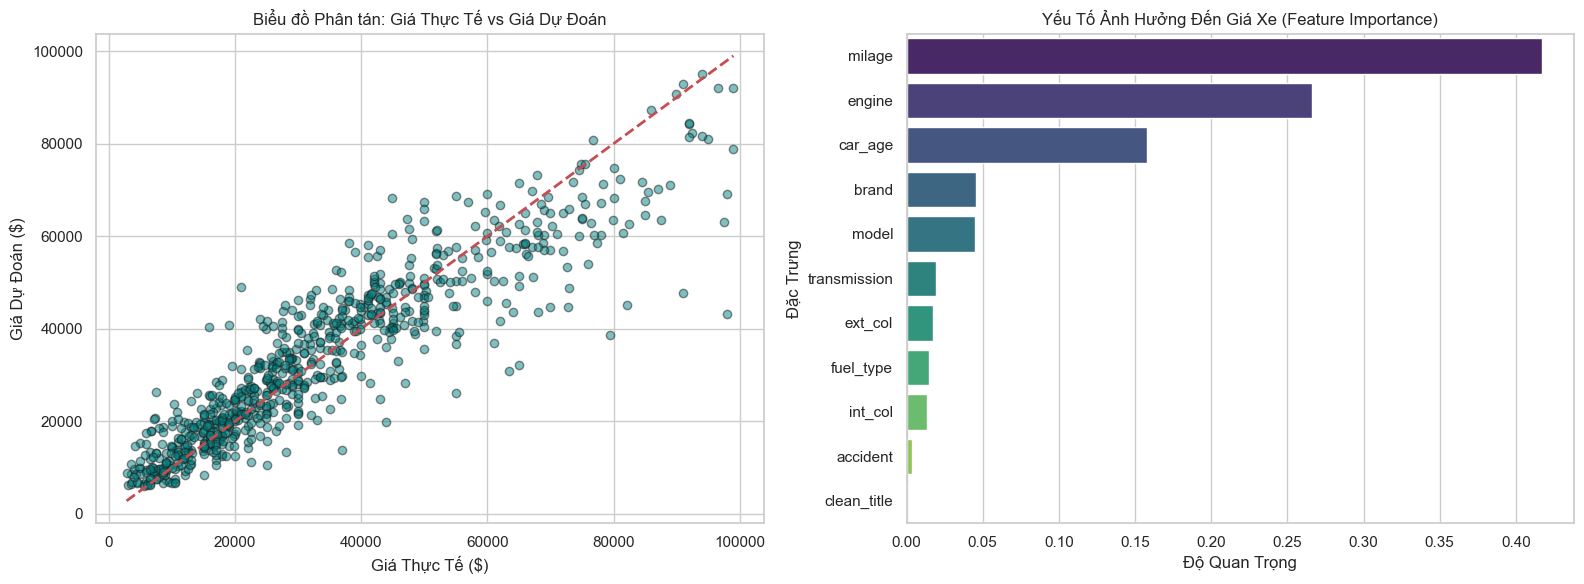

In [7]:
# Cài đặt lại kích thước font chữ cho dễ nhìn
sns.set_theme(style="whitegrid", rc={"axes.labelsize": 12})

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Thực tế vs Dự đoán
axs[0].scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolor='k')
# Vẽ đường chéo lý tưởng 45 độ
axs[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axs[0].set_xlabel('Giá Thực Tế ($)')
axs[0].set_ylabel('Giá Dự Đoán ($)')
axs[0].set_title('Biểu đồ Phân tán: Giá Thực Tế vs Giá Dự Đoán')

# Biểu đồ 2: Mức độ quan trọng của các đặc trưng (Feature Importance)
importances = model.feature_importances_
features = X.columns
# Sắp xếp index theo độ quan trọng giảm dần
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=np.array(features)[indices], palette='viridis', ax=axs[1])
axs[1].set_title('Yếu Tố Ảnh Hưởng Đến Giá Xe (Feature Importance)')
axs[1].set_xlabel('Độ Quan Trọng')
axs[1].set_ylabel('Đặc Trưng')

plt.tight_layout()
plt.show()